In [29]:
from pystac_client import Client
import pandas as pd
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import xarray as xr
from distributed import LocalCluster

Setup


In [30]:
# Create local processing cluster
cluster = LocalCluster()
client = cluster.get_client()

harz_boundaries = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
#bbox = harz_boundaries.geometry.values[0].bounds
bbox = [10.633501, 51.611195, 10.787234, 51.698098]
catalog = Client.open("https://stac.core.eopf.eodc.eu")

D:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 50910 instead
  warnings.warn(


In [31]:
results = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=["2025-04-30", "2025-05-01"],
)
items = results.item_collection()

sr_datasets = []

for item in items:
    # Open SR_20m asset for this item
    ds = xr.open_dataset(item.assets["SR_10m"].href, engine="eopf-zarr", chunks={}, decode_timedelta=True)

    # Expand a time dimension using the item's timestamp
    ds = ds.expand_dims(time=pd.to_datetime([item.datetime]).tz_localize(None))

    sr_datasets.append(ds)

# Combine all items into one Dataset along time
r10m = xr.concat(sr_datasets, dim="time", join="outer")
r10m

<xarray.Dataset> Size: 4GB
Dimensions:      (time: 1, y: 10980, x: 10980)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 88kB 600005 600015 600025 ... 709775 709785 709795
    spatial_ref  int64 8B ...
Data variables:
    b02          (time, y, x) float64 964MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 964MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 964MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 964MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

In [32]:
import xarray as xr
import zarr
import dask.array as da
import pandas as pd

catalog = Client.open("https://stac.core.eopf.eodc.eu")
results = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=["2025-04-20", "2025-05-01"],
)
items = results.item_collection()

sr_datasets = []

for item in items:
    # ------------------------------------------------------------------
    # 1. Open SR_20m
    # ------------------------------------------------------------------
    ds = xr.open_dataset(
        item.assets["SR_20m"].href,
        engine="eopf-zarr",
        chunks={}
    )

    # ------------------------------------------------------------------
    # 2. Open SCL_20m as a Dask-backed DataArray
    # ------------------------------------------------------------------
    scl_z = zarr.open(item.assets["SCL_20m"].href, mode="r")
    scl_da = xr.DataArray(
        da.from_array(scl_z, chunks=scl_z.chunks),
        dims=("y", "x"),
        name="scl"
    )

    # ------------------------------------------------------------------
    # 3. Add SCL as a new variable to the dataset
    # ------------------------------------------------------------------
    ds = ds.assign(scl=scl_da)

    # ------------------------------------------------------------------
    # 4. Add time dimension consistent with SR dataset
    # ------------------------------------------------------------------
    ds = ds.expand_dims(time=pd.to_datetime([item.datetime]).tz_localize(None))

    sr_datasets.append(ds)

# ----------------------------------------------------------------------
# 5. Combine all datasets into a single time stack
# ----------------------------------------------------------------------
r20m_mask_l2a_classification = xr.concat(sr_datasets, dim="time", join="outer")
r20m_mask_l2a_classification

<xarray.Dataset> Size: 12GB
Dimensions:      (time: 5, y: 5490, x: 5490)
Coordinates:
  * time         (time) datetime64[ns] 40B 2025-04-30T10:27:01.024000 ... 202...
  * y            (y) int64 44kB 5800010 5799990 5799970 ... 5690250 5690230
  * x            (x) int64 44kB 600010 600030 600050 ... 709750 709770 709790
    spatial_ref  int64 8B 0
Data variables:
    b01          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b07          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b11          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b12          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    scl          (time, y, x) uint8 151MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [33]:
factor = 10
r100m = r10m.coarsen(x=factor, y=factor, boundary="trim").mean()
r100m

<xarray.Dataset> Size: 39MB
Dimensions:      (time: 1, y: 1098, x: 1098)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 10MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b03          (time, y, x) float64 10MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b04          (time, y, x) float64 10MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b08          (time, y, x) float64 10MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>

In [34]:

target_chunks = {dim: ch[0] for dim, ch in zip(r100m["b02"].dims, r100m["b02"].chunks)}

# Interpolate and rechunk the SCL layer
scl_100m = (
    r20m_mask_l2a_classification.scl
    .chunk({"x": -1, "y": -1})  # merge chunks along x and y for interpolation
    .interp(x=r100m["x"], y=r100m["y"], method="nearest")
    .chunk(target_chunks)        # apply target chunks from r100m
)

scl_100m

<xarray.DataArray 'scl' (time: 5, y: 1098, x: 1098)> Size: 48MB
dask.array<rechunk-merge, shape=(5, 1098, 1098), dtype=float64, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 40B 2025-04-30T10:27:01.024000 ... 202...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0

In [59]:
scl_100m

<xarray.DataArray 'scl' (time: 1, y: 1098, x: 1098)> Size: 10MB
dask.array<getitem, shape=(1, 1098, 1098), dtype=float64, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0

In [37]:
from modules.utils import validate_scl

valid_mask = validate_scl(scl_100m)
valid_r100m = r100m.where(valid_mask)
valid_r100m

<xarray.Dataset> Size: 39MB
Dimensions:      (time: 1, y: 1098, x: 1098)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 10MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b03          (time, y, x) float64 10MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b04          (time, y, x) float64 10MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b08          (time, y, x) float64 10MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>

In [38]:
%%time

band2 = "b02"
band3 = "b03"
band4 = "b04"
band8 = "b08"

red = (
    valid_r100m[band4] * valid_r100m[band4].attrs["_eopf_attrs"]["scale_factor"]
    + valid_r100m[band4].attrs["_eopf_attrs"]["add_offset"]
)


nir = (
    valid_r100m[band8] * valid_r100m[band8].attrs["_eopf_attrs"]["scale_factor"]
    + valid_r100m[band8].attrs["_eopf_attrs"]["add_offset"]
)

ndvi = (nir - red) / (nir + red)  # Per-pixel NDVI
ndvi

CPU times: total: 0 ns
Wall time: 7.57 ms


<xarray.DataArray (time: 1, y: 1098, x: 1098)> Size: 10MB
dask.array<truediv, shape=(1, 1098, 1098), dtype=float64, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0
Attributes: (11)

In [39]:
%%time
# Stack bands and NDVI, scale to match Sentinel Hub
# Not sure if we need to concat in this way? can keep it as data arrays in the dataset may be here??

scale = xr.concat(
    [valid_r100m[band4], valid_r100m[band3], valid_r100m[band2], ndvi], dim="bands"
)
cloudless_ndvi = scale.rename("data").assign_coords(bands=[band4, band3, band2, "ndvi"])

cloudless_ndvi

CPU times: total: 15.6 ms
Wall time: 9.54 ms


<xarray.DataArray 'data' (bands: 4, time: 1, y: 1098, x: 1098)> Size: 39MB
dask.array<concatenate, shape=(4, 1, 1098, 1098), dtype=float64, chunksize=(1, 1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * bands        (bands) <U4 64B 'b04' 'b03' 'b02' 'ndvi'
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0
Attributes: (13)

In [40]:
from ipyleaflet import Map, Polygon

epsg = 32632

center = ((bbox[1] + bbox[3]) / 2.0, (bbox[0] + bbox[2]) / 2.0)
m = Map(center=center, zoom=11)
# Create polygon from lists of points
polygon = Polygon(
    locations=[
        (bbox[1], bbox[0]),
        (bbox[3], bbox[0]),
        (bbox[3], bbox[2]),
        (bbox[1], bbox[2]),
    ],
    color="green",
    fill_color="green",
)

# Add the polygon to the map
m.add(polygon)
m

Map(center=[51.6546465, 10.7103675], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

In [41]:
from shapely import geometry

bbox_polygon = geometry.box(*bbox)

polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[bbox_polygon])
bbox_reproj = polygon.to_crs("epsg:" + str(epsg)).geometry.values[0].bounds
bbox_reproj

(612890.0057926236, 5719059.568597787, 623750.1130221735, 5728972.640384748)

In [42]:
scaling_factor_band4 = r100m[band4].attrs["_eopf_attrs"]["scale_factor"]
add_offset_band4 = r100m[band4].attrs["_eopf_attrs"]["add_offset"]

In [43]:
x_slice = slice(bbox_reproj[0], bbox_reproj[2])
y_slice = slice(bbox_reproj[3], bbox_reproj[1])

region = cloudless_ndvi.sel(x=x_slice, y=y_slice).chunk(
    {"time": "auto", "y": "auto", "x": "auto"}
)
region = region.to_dataset()
region.data_vars.items()

ItemsView(Data variables:
    data     (bands, time, y, x) float64 349kB dask.array<chunksize=(1, 1, 100, 109), meta=np.ndarray>)

In [44]:
%%time
rgb = (
    region.sel(time="20180601", method="nearest").sel(bands=slice(band4, band2))
    * scaling_factor_band4
    + add_offset_band4
)
rgb = (rgb - 0.02) / (0.35 - 0.02)  # Stretch 0.02-0.35 to 0-1
rgb = rgb.clip(0, 1)
rgb.load()

CPU times: total: 1 s
Wall time: 4.27 s


<xarray.Dataset> Size: 263kB
Dimensions:      (bands: 3, y: 100, x: 109)
Coordinates:
  * bands        (bands) <U4 48B 'b04' 'b03' 'b02'
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    time         datetime64[ns] 8B 2025-04-30T10:27:01.024000
    spatial_ref  int64 8B 0
Data variables:
    data         (bands, y, x) float64 262kB nan nan nan nan ... 0.0 0.0 0.0 0.0

In [45]:
ndvi = region.sel(time="20180601", method="nearest").sel(bands="ndvi")
ndvi.load()

<xarray.Dataset> Size: 89kB
Dimensions:      (x: 109, y: 100)
Coordinates:
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
    time         datetime64[ns] 8B 2025-04-30T10:27:01.024000
    spatial_ref  int64 8B 0
    bands        <U4 16B 'ndvi'
Data variables:
    data         (y, x) float64 87kB nan nan nan ... -0.0001088 -0.0001155

In [46]:
ndvi.data

<xarray.DataArray 'data' (y: 100, x: 109)> Size: 87kB
array([[            nan,             nan,             nan, ...,
        -1.09635257e-04, -6.00506193e-05,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       ...,
       [-1.46737781e-04, -1.69072806e-04, -1.91573535e-04, ...,
        -1.11106524e-04, -9.94267872e-05, -9.61798214e-05],
       [-1.46733310e-04, -1.71534113e-04, -1.83650428e-04, ...,
        -1.09909237e-04, -1.12911943e-04, -9.60358219e-05],
       [-1.45208870e-04, -1.62787513e-04, -1.74877945e-04, ...,
        -1.10759027e-04, -1.08838710e-04, -1.15453611e-04]],
      shape=(100, 109))
Coordinates:
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    time         datetime64[ns] 8B 2025-04-30T10:27:01.024000
    spatial_ref  int64 8B 0
    bands        <U4 16B 'ndvi'
Attributes: (13)

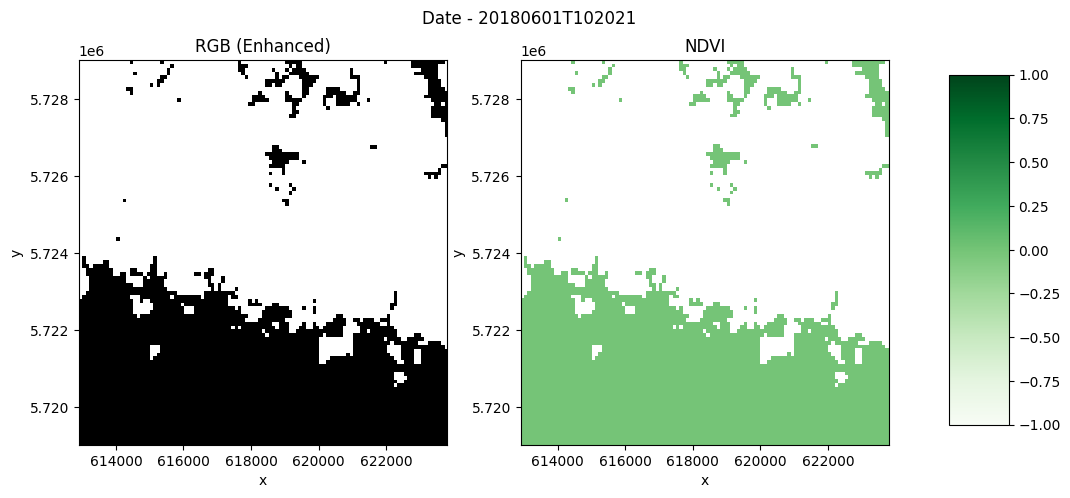

In [61]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Date - 20180601T102021\n")

# First subplot
rgb.data.plot.imshow(
    ax=ax1,
    rgb="bands",
    extent=(x_slice.start, x_slice.stop, y_slice.start, y_slice.stop),
)

ax1.set_title("RGB (Enhanced)")

# Second plot
ndvi_plot = ndvi.data.plot(ax=ax2, cmap="Greens", vmin=-1, vmax=1, add_colorbar=False)
ax2.set_title("NDVI")

# Add color bar on the right
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(ndvi_plot, cax=cbar_ax)

In [48]:
%%time
# Group by year and compute mean
# yearly_da = bbox_reproj.groupby("time.year").mean(dim="time", skipna=True)
yearly_da = (
    cloudless_ndvi.sel(x=x_slice, y=y_slice)
    .groupby("time.year")
    .mean(dim="time", skipna=True)
)

year = 2025  # Adjust if more years
region = yearly_da.sel(year=year, x=x_slice, y=y_slice)

region

CPU times: total: 15.6 ms
Wall time: 8.9 ms


<xarray.DataArray 'data' (bands: 4, year: 1, y: 100, x: 109)> Size: 349kB
dask.array<transpose, shape=(4, 1, 100, 109), dtype=float64, chunksize=(1, 1, 78, 55), chunktype=numpy.ndarray>
Coordinates:
  * bands        (bands) <U4 64B 'b04' 'b03' 'b02' 'ndvi'
  * year         (year) int64 8B 2025
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    spatial_ref  int64 8B 0
Attributes: (13)

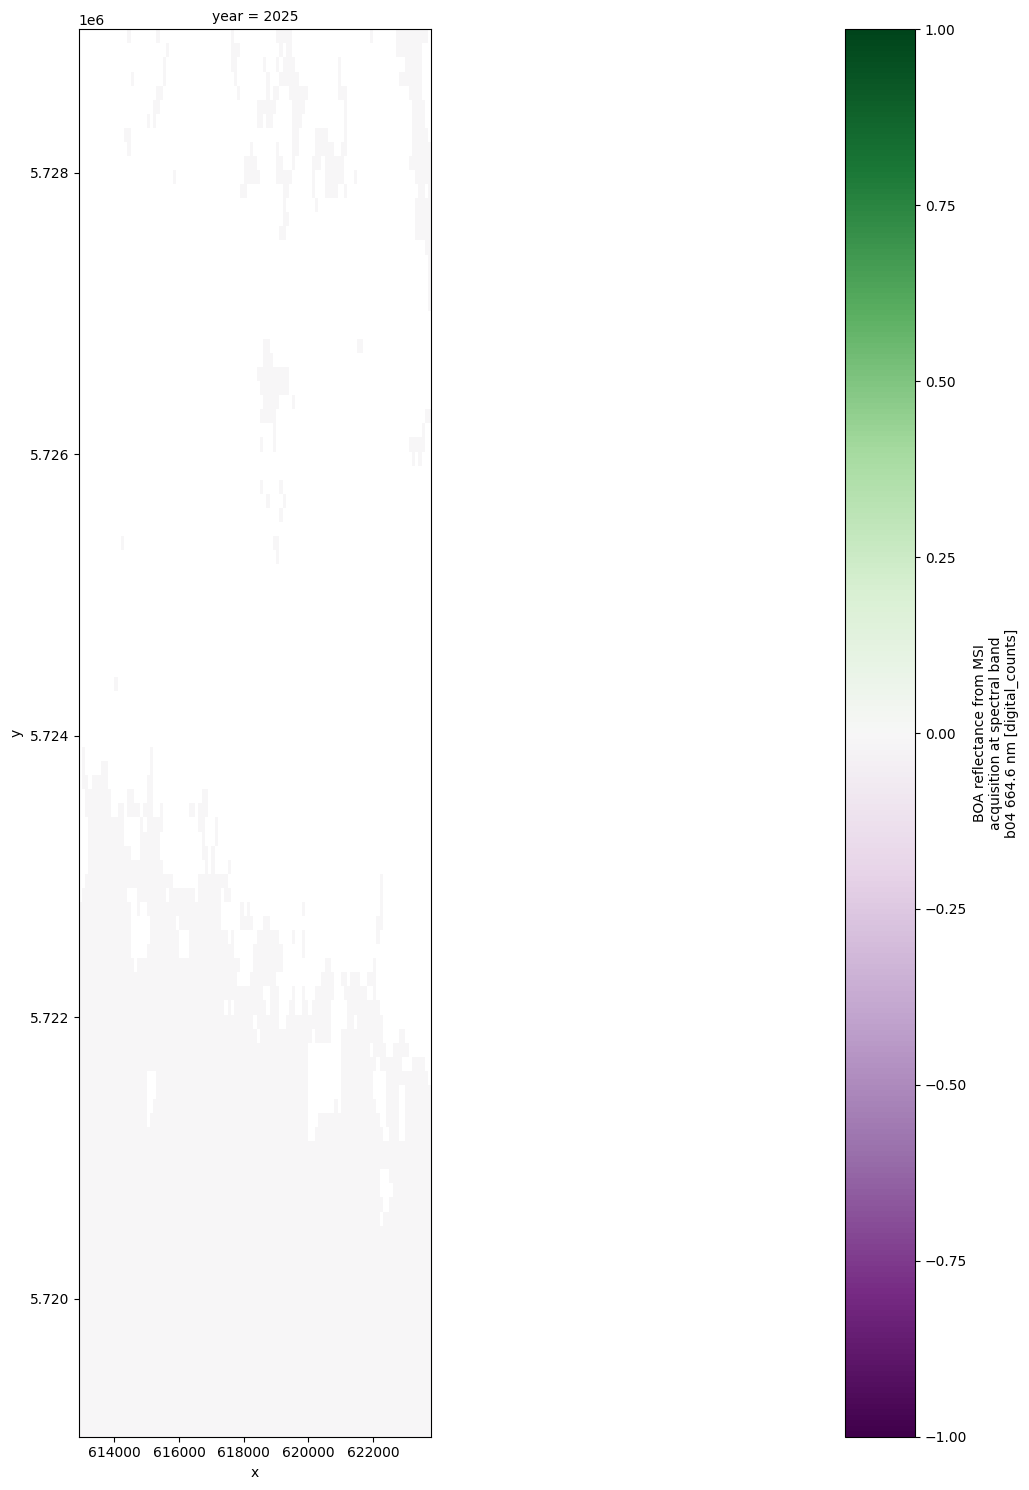

In [52]:
ndvi_yearly = yearly_da.sel(bands="ndvi", x=x_slice, y=y_slice).sel(
    year=slice(2018, 2018)
)

ndvi_yearly.plot(
    cmap="PRGn", x="x", y="y", col="year", col_wrap=2, vmin=-1, vmax=1, figsize=(10, 15)
)

In [53]:
ndvi_ds = xr.Dataset(
    {
        "NDVI": yearly_da.sel(bands="ndvi").drop_vars("bands"),
        "B04": yearly_da.sel(bands=band4).drop_vars("bands"),
        "B03": yearly_da.sel(bands=band3).drop_vars("bands"),
        "B02": yearly_da.sel(bands=band2).drop_vars("bands"),
    }
)
ndvi_ds

<xarray.Dataset> Size: 350kB
Dimensions:      (x: 109, y: 100, year: 1)
Coordinates:
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * year         (year) int64 8B 2025
    spatial_ref  int64 8B 0
Data variables:
    NDVI         (year, y, x) float64 87kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    B04          (year, y, x) float64 87kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    B03          (year, y, x) float64 87kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    B02          (year, y, x) float64 87kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>

In [54]:
ndvi_ds.data_vars.items()

ndvi_ds = ndvi_ds.chunk({"year": 1, "y": 50, "x": 55})
print(ndvi_ds)
print(ndvi_ds.chunks)

<xarray.Dataset> Size: 350kB
Dimensions:      (x: 109, y: 100, year: 1)
Coordinates:
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * year         (year) int64 8B 2025
    spatial_ref  int64 8B 0
Data variables:
    NDVI         (year, y, x) float64 87kB dask.array<chunksize=(1, 50, 55), meta=np.ndarray>
    B04          (year, y, x) float64 87kB dask.array<chunksize=(1, 50, 55), meta=np.ndarray>
    B03          (year, y, x) float64 87kB dask.array<chunksize=(1, 50, 55), meta=np.ndarray>
    B02          (year, y, x) float64 87kB dask.array<chunksize=(1, 50, 55), meta=np.ndarray>
Frozen({'year': (1,), 'y': (50, 50), 'x': (55, 54)})


In [55]:
ndvi_ds["FOREST"] = ndvi_ds.NDVI > 0.5
ndvi_ds["FOREST"]

<xarray.DataArray 'FOREST' (year: 1, y: 100, x: 109)> Size: 11kB
dask.array<gt, shape=(1, 100, 109), dtype=bool, chunksize=(1, 50, 55), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 8B 2025
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    spatial_ref  int64 8B 0
Attributes: (13)

In [56]:
import numpy as np


def to_km2(dataarray, resolution):
    # Calculate forest area
    return dataarray * np.prod(list(resolution)) / 1e6

resolution = (10 * factor, 10 * factor)
print("factor = ", factor, "resolution = ", resolution)
forest_pixels = ndvi_ds.sel(x=x_slice, y=y_slice).FOREST.sum(["x", "y"])
forest_area_km2 = to_km2(forest_pixels, resolution)
forest_area_km2

factor =  10 resolution =  (100, 100)


<xarray.DataArray 'FOREST' (year: 1)> Size: 8B
dask.array<truediv, shape=(1,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 8B 2025
    spatial_ref  int64 8B 0
Attributes: (13)

In [57]:
forest_area_km2.load()

forest_area_km2.plot()

plt.title("Forest Cover")
plt.ylabel("Forest Cover [km²]")
plt.ylim(0);

TypeError: No numeric data to plot.

In [41]:
forest_area_km2

<xarray.DataArray 'FOREST' (year: 1)> Size: 8B
array([0.])
Coordinates:
  * year         (year) int64 8B 2025
    spatial_ref  int64 8B 0
Attributes: (13)